In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
class WindowDataset(Dataset):
    # 단변량 시계열에서 입력 값 정답 값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태의 1차원 tensor 데이터
        # _window : 과거의 몇 개의 데이터를 볼것인가? (구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수는 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window

    def __len__(self):
        return max(self.n, 0)
    
    # __len__(), __getitem__() 두개의 특수 함수들은 DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __getitem__(self, idx):
        # 변환
        # x -> 입력 데이터 (윈도우의 구간을 나타내는 데이터) --> 문제
        # y -> 입력 데이터 다음 행의 데이터 --> 정답
        x = self.data[idx : idx + self.window].unsqueeze(-1)   # (window, ) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x, y

In [45]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, forward()함수

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers = 1,
            nonlinearity = 'tanh',
            dropout = 0.0,
            bidirectional = False,
            batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            nonlinearity = nonlinearity,
            dropout = dropout,
            bidirectional = bidirectional,
            batch_first = batch_first
        )
        # self.head = nn.Linear(hidden_size, 1)   # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우엔 hidden_size를 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        # 선형 학습 모델 -> 비선형 학습 모델
        # self.head = nn.Linear(out_features, 1)
        self.head = nn.Sequential(
            nn.Linear(out_features, out_features*2),
            nn.ReLU(),
            nn.Linear(out_features*2, 1)
        )

    def forward(self, x):
        # out -> 모든 시점에서의 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값 -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

### 문제
- csv 폴더 안에 있는 AAPL.csv 파일을 로드
- 해당 데이터프레임에서 Date, Adj Close 컬럼을 제외한 나머지는 모두 삭제
- 결측치가 포함되어있는지 확인하고 결측치 데이터가 전체 데이터 수의 비해 매우 작은 크기라면 제거
- 해당 데이터셋의 순서가 시간의 순서와 같은지 확인 (시간 컬럼을 기준으로 오름차순 정렬)
- tensor 데이터를 생성하기 위해 Adj Close의 데이터 array형태로 변경
- train, test의 비율이 75:25의 비율로 데이터를 나눠준다.
- train과 test를 스케일러를 이용하여 스케일링
- train과 test를 Tensor의 형태로 변환
- Tensor의 형태로 변환된 데이터를 WindowDataset의 형태로 변경하고 DataLoader를 이용하여 학습에서 사용하기 편한 형태로 변경

In [46]:
df = pd.read_csv('../csv/AAPL.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   object 
 1   Open       9714 non-null   float64
 2   High       9714 non-null   float64
 3   Low        9714 non-null   float64
 4   Close      9714 non-null   float64
 5   Adj Close  9714 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 531.4+ KB


In [47]:
# Date, Adj Close 컬럼을 제외한 나머지는 모두 제거
df2 = df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1)
df2

,Date,Adj Close
0,1980-12-12,0.410525
1,1980-12-15,0.389106
2,1980-12-16,0.360548
3,1980-12-17,0.369472
4,1980-12-18,0.380182
...,...,...
9710,2019-06-18,198.449997
9711,2019-06-19,197.869995
9712,2019-06-20,199.460007
9713,2019-06-21,198.779999


In [48]:
df = df[['Date', 'Adj Close']]

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   object 
 1   Adj Close  9714 non-null   float64
dtypes: float64(1), object(1)
memory usage: 151.9+ KB


In [50]:
# 결측치의 개수 / 전체 데이터의 개수 * 100
# 결측치가 포함된 행의 개수
na_cnt = df.isna().any(axis=1).sum()
round(na_cnt / len(df) * 100, 2)

np.float64(0.01)

In [51]:
# 결측치의 개수가 전체 데이터에 비해 매우 작다 -> 그냥 제거
# 결측치가 포함되어있는 행을 제외하고 필터링
df.loc[~df.isna().any(axis=1), ]

,Date,Adj Close
0,1980-12-12,0.410525
1,1980-12-15,0.389106
2,1980-12-16,0.360548
3,1980-12-17,0.369472
4,1980-12-18,0.380182
...,...,...
9710,2019-06-18,198.449997
9711,2019-06-19,197.869995
9712,2019-06-20,199.460007
9713,2019-06-21,198.779999


In [52]:
# 결측치가 포함되어있는 행을 제거
df.dropna(axis=0, inplace=True)

In [53]:
# Data을 기준으로 오름차순 정렬
df.sort_values('Date', inplace = True)

In [54]:
# Adj Close의 values을 2차원 array의 형태로 변환
df['Adj Close'].values.reshape(-1, 1)

array([[  0.410525],
       [  0.389106],
       [  0.360548],
       ...,
       [199.460007],
       [198.779999],
       [199.169998]], shape=(9714, 1))

In [ ]:
values = df[['Adj Close']].values

In [56]:
# 75 : 25 비율로 데이터 분할
split_idx = int(len(values) * 0.75)

train_data = values[ : split_idx]
test_data = values[split_idx : ]
print(train_data.shape, test_data.shape)

(7285, 1) (2429, 1)


In [57]:
# StandardScaler 스케일러를 이용하여 스케일링 작업
scaler = MinMaxScaler()
train_sc = scaler.fit_transform(train_data)
test_sc = scaler.transform(test_data)

In [58]:
# 스케일링이 완료된 데이터셋을 tensor형태로 변환
train_sc = torch.tensor(train_sc.squeeze(-1), dtype=torch.float32)
test_sc = torch.tensor(test_sc.squeeze(-1), dtype=torch.float32)

In [59]:
train_ds = WindowDataset(train_sc, 60)
test_ds = WindowDataset(test_sc, 60)

In [ ]:
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=128)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)

In [92]:
# 반복 학습 루프 생성
# 모델 생성
aapl_model = RNNReg(input_size=1, hidden_size=128)
# 손실함수
criterion = nn.MSELoss()
# 옵티마이저
optimizer = optim.Adam(aapl_model.parameters(), lr=0.001)

In [93]:
# 평가 함수 생성
# 함수 호출시 동시에 실행이 되는 데코레이터 생성
@torch.no_grad()
def evaluate_mse(dataloader):
    aapl_model.eval()
    total_loss, total_n = 0.0, 0
    # with torch,no_grad():
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        yhat = aapl_model(x)
        loss = criterion(yhat, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

train_history, val_history = [], []
for epoch in range(20):
    aapl_model.train()
    running, n_seen = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        optimizer.zero_grad()
        yhat = aapl_model(x)
        loss = criterion(yhat, y)
        loss.backward()

        # 기울기 폭발 방지 -> nan값이 나올 수 있는 확률은 배제
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)

        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaluate_mse(test_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f'Epoch : {epoch+1}, train_mse = {round(train_mse, 4)}, val_mse : {round(val_mse, 4)}')

Epoch : 1, train_mse = 0.0052, val_mse : 3.729
Epoch : 2, train_mse = 0.0001, val_mse : 3.2908
Epoch : 3, train_mse = 0.0001, val_mse : 3.1747
Epoch : 4, train_mse = 0.0001, val_mse : 2.8643
Epoch : 5, train_mse = 0.0001, val_mse : 2.5723
Epoch : 6, train_mse = 0.0001, val_mse : 2.5338
Epoch : 7, train_mse = 0.0001, val_mse : 2.2664
Epoch : 8, train_mse = 0.0001, val_mse : 2.2237
Epoch : 9, train_mse = 0.0001, val_mse : 2.0805
Epoch : 10, train_mse = 0.0001, val_mse : 1.9795
Epoch : 11, train_mse = 0.0001, val_mse : 1.7163
Epoch : 12, train_mse = 0.0001, val_mse : 1.7232
Epoch : 13, train_mse = 0.0001, val_mse : 1.7591
Epoch : 14, train_mse = 0.0001, val_mse : 1.4543
Epoch : 15, train_mse = 0.0001, val_mse : 1.3662
Epoch : 16, train_mse = 0.0001, val_mse : 1.2852
Epoch : 17, train_mse = 0.0001, val_mse : 1.4398
Epoch : 18, train_mse = 0.0001, val_mse : 1.3673
Epoch : 19, train_mse = 0.0001, val_mse : 1.1993
Epoch : 20, train_mse = 0.0001, val_mse : 1.1136


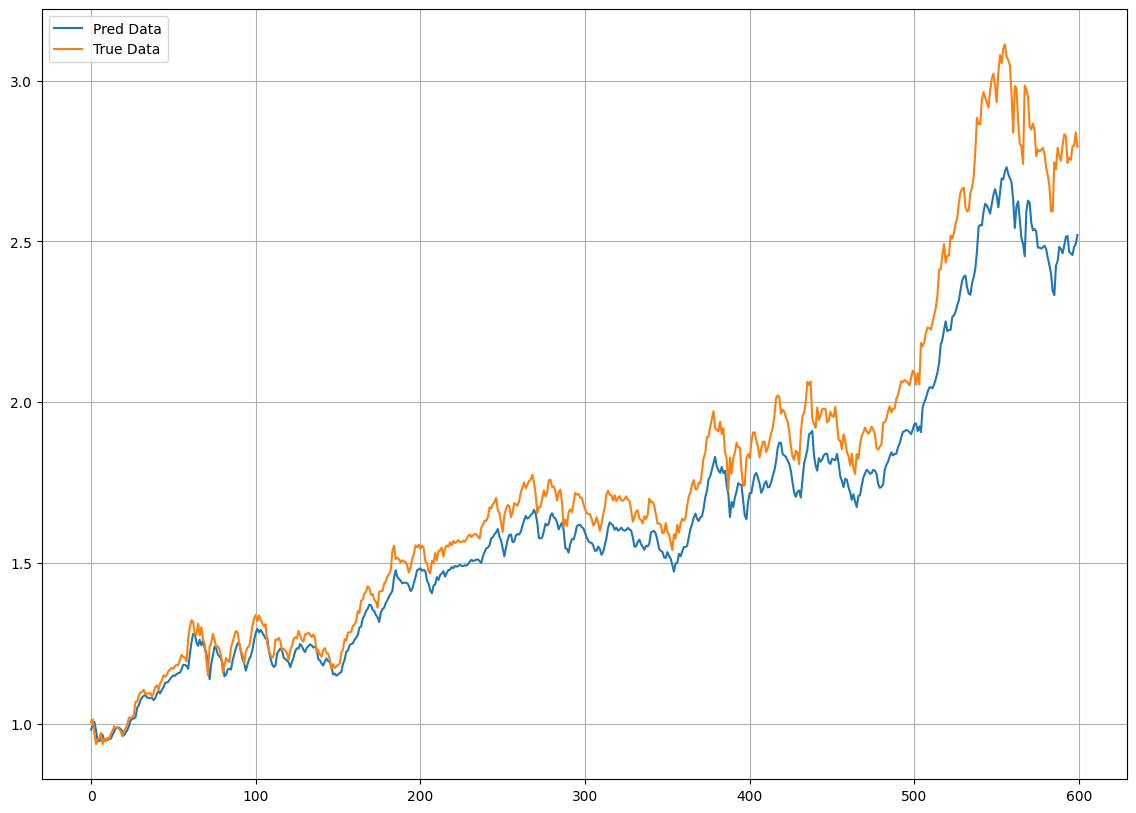

In [94]:
# 검증 셋 예측의 값과 실제의 값을 그래프 시각화
aapl_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        yhat = aapl_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

# preds, trues를 numpy형태로 변환
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(14, 10))
plt.plot(preds[:600], label='Pred Data')
plt.plot(trues[:600], label='True Data')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
# 스케일링 데이터를 다시 원본의 데이터셋으로 변경
# inverse_transform() : 스케일링 데이터를 원본으로 변경
preds_origin = scaler.inverse_transform(preds.reshape(-1, 1)).squeeze()
trues_origin = scaler.inverse_transform(trues.reshape(-1, 1)).squeeze()

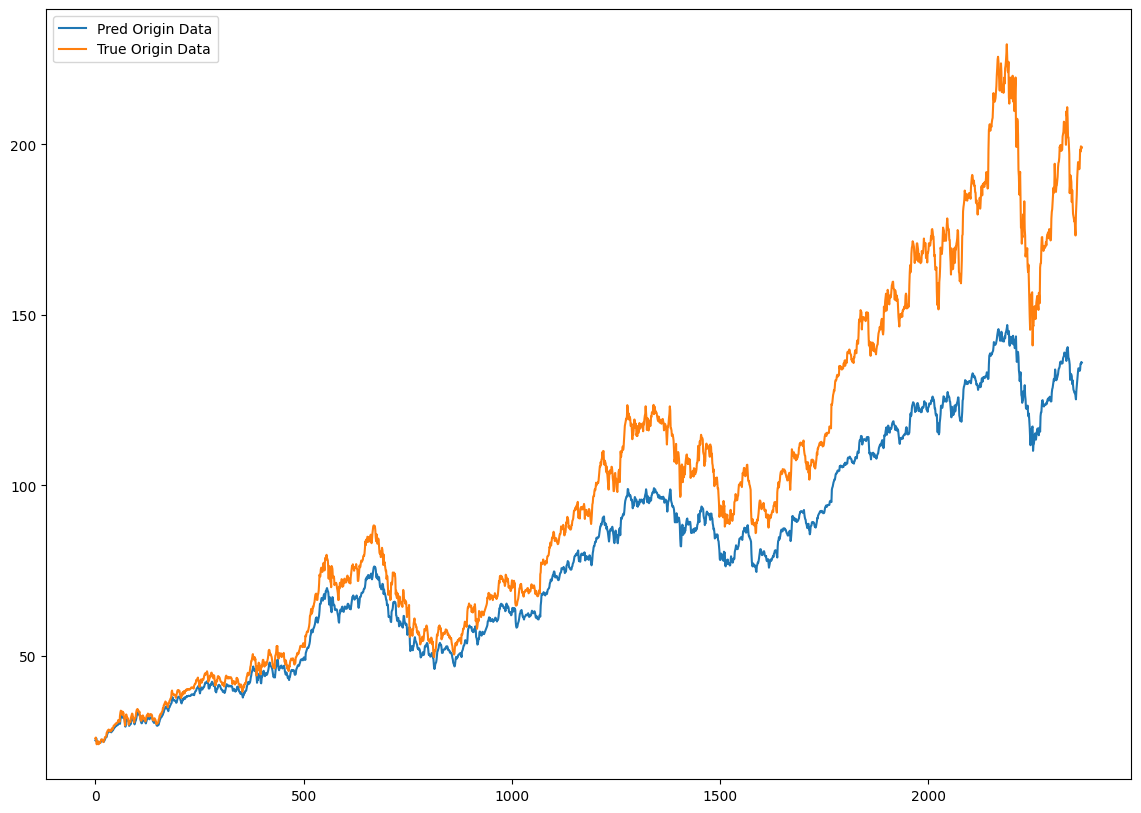

In [96]:
plt.figure(figsize=(14, 10))
plt.plot(preds_origin, label='Pred Origin Data')
plt.plot(trues_origin, label='True Origin Data')

plt.legend()

plt.show()

In [97]:
# 시계열 분석
# 2개의 피쳐(종가, 거래량) -> 타깃(종가) 예측

df = pd.read_csv("../csv/AAPL.csv")

In [102]:
# 특정 컬럼을 선택
df = df[['Date', 'Adj Close', 'Volume']]
df.dropna(axis=0, inplace=True)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9713 entries, 0 to 9714
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9713 non-null   object 
 1   Adj Close  9713 non-null   float64
 2   Volume     9713 non-null   float64
dtypes: float64(2), object(1)
memory usage: 303.5+ KB


In [104]:
# 피쳐 데이터(독립)
X_all = df[['Adj Close', 'Volume']].astype('float').values
# 타깃 데이터
Y_all = df[['Adj Close']].astype('float').values

In [105]:
# 데이터의 분할 -> 4개의 데이터가 생성 -> 8:2
split_idx = int(len(df) * 0.8)

X_train, X_test = X_all[ : split_idx], X_all[split_idx : ]
Y_train, Y_test = Y_all[ : split_idx], Y_all[split_idx : ]

In [106]:
# 스케일러를 스케일링 -> (마지막에 예측 종가, 실제 종가의 데이터의 원본으로 역변환을 편하게 하기 위함)
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc = x_scaler.transform(X_test)

Y_train_sc = y_scaler.fit_transform(Y_train)
Y_test_sc = y_scaler.transform(Y_test)

In [110]:
# DataLoader에서 구간 데이터를 나눠주기 위한 Dataset 구성
class WindowDataset(Dataset):
    def __init__(self, _x, _y, _window):
        # _x : 독립
        # _y : 종속
        # _window : 구간
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window
    #  DataLoader에서 사용되는 특수 메서드 정의 : __len__(), __getitem__()
    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        # 입력데이터(문제)
        x_window = self.x[idx : idx + self.window]
        # 타깃 데이터(정답)
        y_next = self.y[idx + self.window]
        # tensor 데이터로 변환 (self.x, self.y를 array형태로 받는다는 가정)
        # tensor() -> 텐서형으로 데이터를 변환 (깊은 복사)
        # from_numpy() -> 텐서형으로 데이터를 변환(얕은 복사 -> 데이터는 위치는 같고 라벨을 추가)
        x_tensor = torch.from_numpy(x_window)
        y_tensor = torch.from_numpy(y_next)
        return x_tensor, y_tensor

In [111]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, forward()함수

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers = 1,
            nonlinearity = 'tanh',
            dropout = 0.0,
            bidirectional = False,
            batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            nonlinearity = nonlinearity,
            dropout = dropout,
            bidirectional = bidirectional,
            batch_first = batch_first
        )
        # self.head = nn.Linear(hidden_size, 1)   # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우엔 hidden_size를 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        # 선형 학습 모델 -> 비선형 학습 모델
        # self.head = nn.Linear(out_features, 1)
        self.head = nn.Sequential(
            nn.Linear(out_features, out_features*2),
            nn.ReLU(),
            nn.Linear(out_features*2, 1)
        )

    def forward(self, x):
        # out -> 모든 시점에서의 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값 -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

In [112]:
# 구간별 데이터셋을 구성
train_ds = WindowDataset(X_train_sc, Y_train_sc, 60)
test_ds = WindowDataset(X_test_sc, Y_test_sc, 60)

train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)

In [117]:
# 반복 학습 루프 생성
# 모델 생성
aapl_model = RNNReg(input_size=2, hidden_size=128)
# 손실함수
criterion = nn.MSELoss()
# 옵티마이저
optimizer = optim.Adam(aapl_model.parameters(), lr=0.001)

In [118]:
# 평가 함수 생성
# 함수 호출시 동시에 실행이 되는 데코레이터 생성
@torch.no_grad()
def evaluate_mse(dataloader):
    aapl_model.eval()
    total_loss, total_n = 0.0, 0
    # with torch,no_grad():
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        yhat = aapl_model(x)
        loss = criterion(yhat, y)
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

train_history, val_history = [], []
for epoch in range(20):
    aapl_model.train()
    running, n_seen = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        optimizer.zero_grad()
        yhat = aapl_model(x)
        loss = criterion(yhat, y)
        loss.backward()

        # 기울기 폭발 방지 -> nan값이 나올 수 있는 확률은 배제
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)

        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaluate_mse(test_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f'Epoch : {epoch+1}, train_mse = {round(train_mse, 4)}, val_mse : {round(val_mse, 4)}')

Epoch : 1, train_mse = 0.0559, val_mse : 26.0435
Epoch : 2, train_mse = 0.0011, val_mse : 24.4933
Epoch : 3, train_mse = 0.0013, val_mse : 22.887
Epoch : 4, train_mse = 0.0008, val_mse : 21.9569
Epoch : 5, train_mse = 0.0013, val_mse : 20.4139
Epoch : 6, train_mse = 0.0014, val_mse : 17.7459
Epoch : 7, train_mse = 0.0011, val_mse : 17.3187
Epoch : 8, train_mse = 0.0011, val_mse : 15.4613
Epoch : 9, train_mse = 0.0008, val_mse : 14.0289
Epoch : 10, train_mse = 0.0008, val_mse : 14.3247
Epoch : 11, train_mse = 0.0007, val_mse : 13.3716
Epoch : 12, train_mse = 0.0008, val_mse : 13.5771
Epoch : 13, train_mse = 0.0007, val_mse : 12.2242
Epoch : 14, train_mse = 0.0009, val_mse : 13.0587
Epoch : 15, train_mse = 0.0008, val_mse : 11.6859
Epoch : 16, train_mse = 0.0008, val_mse : 12.0018
Epoch : 17, train_mse = 0.0008, val_mse : 12.9217
Epoch : 18, train_mse = 0.0012, val_mse : 11.4075
Epoch : 19, train_mse = 0.0008, val_mse : 11.3185
Epoch : 20, train_mse = 0.0009, val_mse : 10.1905


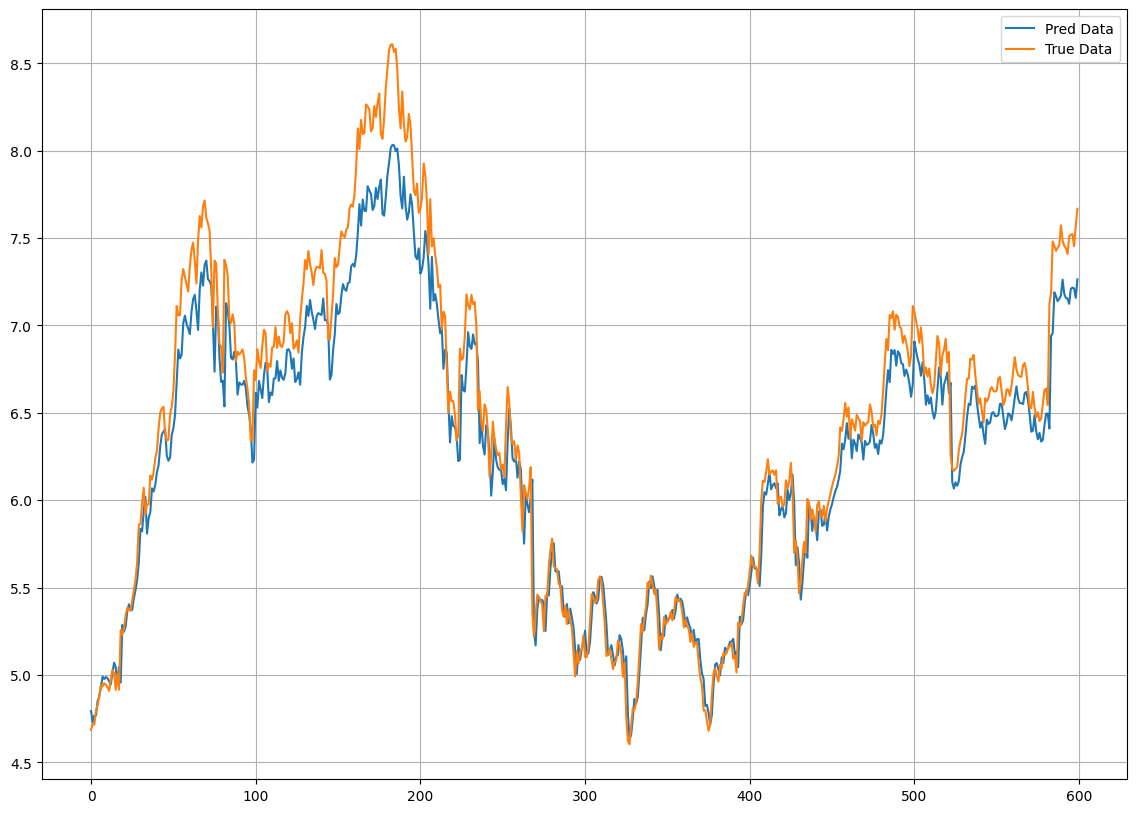

In [119]:
# 검증 셋 예측의 값과 실제의 값을 그래프 시각화
aapl_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        yhat = aapl_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

# preds, trues를 numpy형태로 변환
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(14, 10))
plt.plot(preds[:600], label='Pred Data')
plt.plot(trues[:600], label='True Data')
plt.legend()
plt.grid(True)
plt.show()

In [120]:
# 스케일링 데이터를 다시 원본의 데이터셋으로 변경
# inverse_transform() : 스케일링 데이터를 원본으로 변경
preds_origin = y_scaler.inverse_transform(preds.reshape(-1, 1)).squeeze()
trues_origin = y_scaler.inverse_transform(trues.reshape(-1, 1)).squeeze()

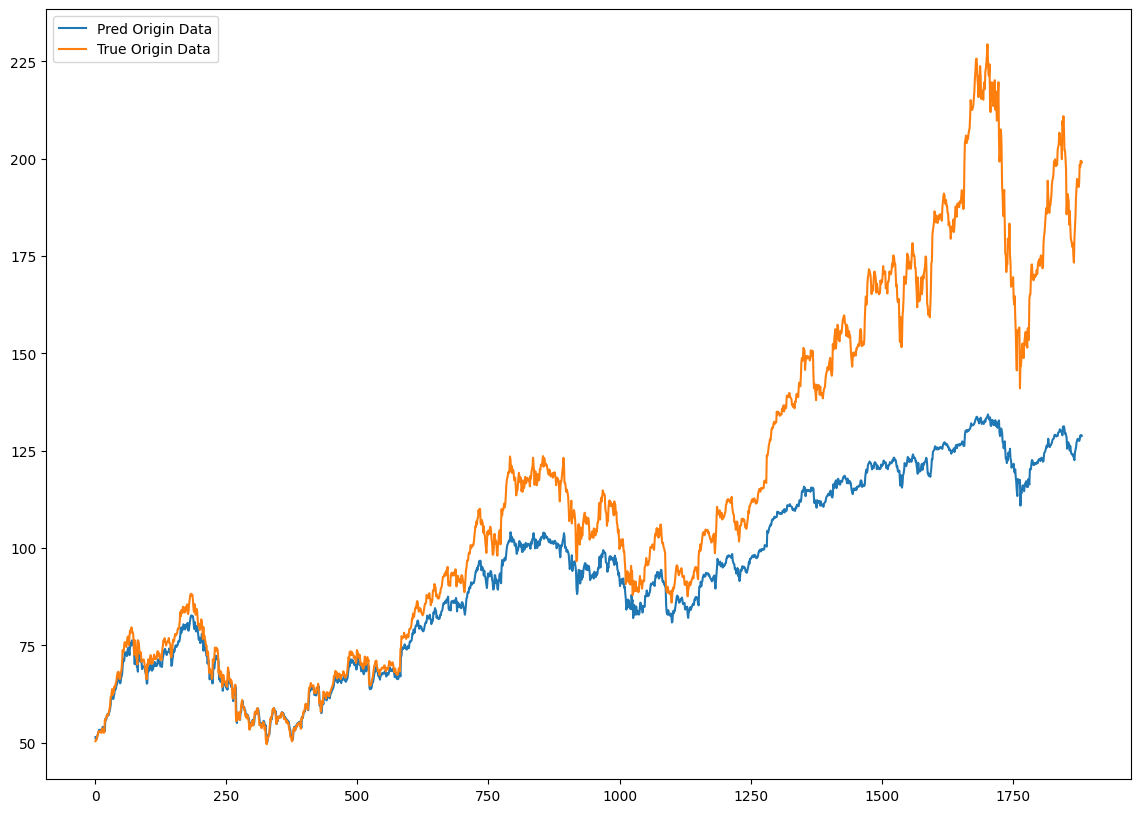

In [121]:
plt.figure(figsize=(14, 10))
plt.plot(preds_origin, label='Pred Origin Data')
plt.plot(trues_origin, label='True Origin Data')

plt.legend()

plt.show()